# **Catch22 — Extracción de Características**

## **Setup**

In [1]:
# Librerías
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pycatch22

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "catch22" else Path.cwd()
RUTA_TRAIN = RAIZ / "datos" / "processed" / "entrenamiento.csv"

print("Setup completado")

Setup completado


In [2]:
# Serie total y series de las categorías seleccionadas (regiones y fronteras), a partir del entrenamiento.
entrenamiento = pd.read_csv(RUTA_TRAIN, parse_dates=["Fecha"])

series = {
    "Total": entrenamiento.groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Región - América Del Centro": entrenamiento[entrenamiento["Región dos"] == "América Del Centro"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Región - América Del Norte": entrenamiento[entrenamiento["Región dos"] == "América Del Norte"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Región - Europa": entrenamiento[entrenamiento["Región dos"] == "Europa"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Frontera - 01 La Aurora": entrenamiento[entrenamiento["Frontera"] == "01 La Aurora"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Frontera - 07 Valle Nuevo": entrenamiento[entrenamiento["Frontera"] == "07 Valle Nuevo"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Frontera - 09 San Cristóbal": entrenamiento[entrenamiento["Frontera"] == "09 San Cristóbal"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
}

for nombre, s in series.items():
    print(f"{nombre:30s} obs={s.shape[0]:3d}  inicio={s.index.min().date()}  fin={s.index.max().date()}  NaN={s.isna().sum()}")

# Meses sin registros para una serie (p.ej. Europa/América del Norte durante el confinamiento de 2020)
# no son dato faltante sino cero viajeros: se rellenan con 0, no se interpolan.
series = {nombre: s.fillna(0.0) for nombre, s in series.items()}

Total                          obs=147  inicio=2009-01-01  fin=2021-03-01  NaN=0
Región - América Del Centro    obs=147  inicio=2009-01-01  fin=2021-03-01  NaN=0
Región - América Del Norte     obs=147  inicio=2009-01-01  fin=2021-03-01  NaN=5
Región - Europa                obs=147  inicio=2009-01-01  fin=2021-03-01  NaN=5
Frontera - 01 La Aurora        obs=147  inicio=2009-01-01  fin=2021-03-01  NaN=0
Frontera - 07 Valle Nuevo      obs=147  inicio=2009-01-01  fin=2021-03-01  NaN=0
Frontera - 09 San Cristóbal    obs=147  inicio=2009-01-01  fin=2021-03-01  NaN=0


## **2.1. ¿Qué es catch22 y por qué es importante?**

catch22 nace de hctsa (*highly comparable time-series analysis*), una librería que calcula más de 7000 características estadísticas para caracterizar una serie de tiempo. Ese conjunto es masivo, lento de calcular y muy redundante (muchas características miden esencialmente lo mismo). catch22 es el resultado de un proceso de selección sobre ese banco de más de 7000 features: se evaluó qué tan bien cada una distinguía entre series de un banco de datos de clasificación muy diverso (miles de series de dominios distintos), y de ahí se escogió un subconjunto de 22 características que, en conjunto, (1) tienen un buen desempeño individual para discriminar entre series, (2) son lo más independientes posible entre sí (poca redundancia), y (3) se pueden calcular en tiempo lineal, de forma rápida y con una implementación ligera en C.

Las 22 características cubren distintas facetas de la dinámica de una serie: forma de la distribución, estructura de autocorrelación, linealidad/no linealidad, entropía y forecastability, y propiedades de escala/fluctuación, entre otras. Es importante porque permite pasar de una serie de tiempo completa a un vector pequeño y comparable de 22 números que resume su comportamiento, algo muy útil para comparar, agrupar (clustering) o clasificar muchas series entre sí de forma barata, sin tener que correr el banco completo de hctsa ni ajustar un modelo completo para cada serie.

## **2.2. Extracción de las 22 características para cada serie**

In [3]:
# catch22 para cada una de las series (serie total + regiones + fronteras seleccionadas).
resultados = {}
for nombre, s in series.items():
    salida = pycatch22.catch22_all(list(s.values), catch24=False)
    resultados[nombre] = dict(zip(salida["names"], salida["values"]))

tabla_catch22 = pd.DataFrame(resultados)
tabla_catch22

,Total,Región - América Del Centro,Región - América Del Norte,Región - Europa,Frontera - 01 La Aurora,Frontera - 07 Valle Nuevo,Frontera - 09 San Cristóbal
DN_HistogramMode_5,0.174564,-0.601979,-0.377447,0.476866,-0.335017,0.286514,-0.232536
DN_HistogramMode_10,-0.580843,-0.356208,-0.136470,0.257594,-0.069026,0.058509,-0.934744
CO_f1ecac,8.105554,8.532877,4.683735,3.779838,6.237583,8.284985,5.461214
CO_FirstMin_ac,10.000000,10.000000,3.000000,7.000000,10.000000,11.000000,7.000000
CO_HistogramAMI_even_2_5,0.467207,0.490904,0.247039,0.314402,0.284910,0.341134,0.340735
CO_trev_1_num,-0.067552,-0.042162,-0.133820,-0.099422,-0.097577,-0.042117,-0.015131
MD_hrv_classic_pnn40,0.917808,0.917808,0.945205,0.938356,0.931507,0.924658,0.876712
SB_BinaryStats_mean_longstretch1,30.000000,42.000000,12.000000,8.000000,42.000000,38.000000,29.000000
SB_TransitionMatrix_3ac_sumdiagcov,0.046296,0.080000,0.025510,0.030000,0.063333,0.046296,0.062500
PD_PeriodicityWang_th0_01,11.000000,11.000000,3.000000,11.000000,11.000000,7.000000,11.000000


## **2.3. Matriz serie × característica**

`tabla_catch22` quedó con las características en filas y las series en columnas (conveniente para inspección). Para el análisis comparativo se necesita la matriz en el formato estándar: una fila por serie, una columna por característica de catch22.

In [4]:
# Matriz serie x característica (filas=series, columnas=características catch22).
matriz = tabla_catch22.T
matriz.index.name = "Serie"
print(f"matriz.shape = {matriz.shape}  (series x características)")
matriz

matriz.shape = (7, 22)  (series x características)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total,0.174564,-0.580843,8.105554,10.0,0.467207,-0.067552,0.917808,30.0,0.046296,11.0,...,0.045455,0.625850,0.891156,0.816813,6.0,1.833320,0.850,0.75,0.147262,0.613916
Región - América Del Centro,-0.601979,-0.356208,8.532877,10.0,0.490904,-0.042162,0.917808,42.0,0.080000,11.0,...,0.038462,0.639456,0.891156,0.821167,6.0,1.855498,0.850,0.75,0.147262,0.603843
Región - América Del Norte,-0.377447,-0.136470,4.683735,3.0,0.247039,-0.133820,0.945205,12.0,0.025510,3.0,...,0.100000,0.312925,0.891156,0.626571,5.0,2.123190,0.850,0.70,0.269981,0.869309
Región - Europa,0.476866,0.257594,3.779838,7.0,0.314402,-0.099422,0.938356,8.0,0.030000,11.0,...,0.071429,0.374150,0.904762,0.705241,6.0,2.105974,0.150,0.70,0.319068,0.815268
Frontera - 01 La Aurora,-0.335017,-0.069026,6.237583,10.0,0.284910,-0.097577,0.931507,42.0,0.063333,11.0,...,0.142857,0.605442,0.891156,0.790485,5.0,1.955550,0.150,0.80,0.171806,0.687132
Frontera - 07 Valle Nuevo,0.286514,0.058509,8.284985,11.0,0.341134,-0.042117,0.924658,38.0,0.046296,7.0,...,0.045455,0.591837,0.571429,0.804835,6.0,1.839140,0.825,0.65,0.147262,0.616151
Frontera - 09 San Cristóbal,-0.232536,-0.934744,5.461214,7.0,0.340735,-0.015131,0.876712,29.0,0.062500,11.0,...,0.033333,0.544218,-0.278912,0.783114,5.0,1.764556,0.150,0.80,0.171806,0.711351


## **2.4. Estandarización**

Las 22 características viven en escalas muy distintas (conteos de rezagos, proporciones entre 0 y 1, longitudes de racha, etc.), así que se estandariza cada columna (media 0, desviación 1) antes de PCA, clustering o distancias — de lo contrario las características con magnitudes más grandes dominarían esos análisis.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
matriz_z = pd.DataFrame(
    scaler.fit_transform(matriz),
    index=matriz.index,
    columns=matriz.columns,
)
matriz_z

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total,0.707006,-0.876346,0.945108,0.658586,1.329767,0.092985,-0.189405,0.100335,-0.237472,0.588348,...,-0.608505,0.812090,0.518005,0.791459,0.866025,-0.704667,0.883979,0.277350,-0.763763,-0.912253
Región - América Del Centro,-1.391946,-0.278438,1.187710,0.658586,1.611077,0.756188,-0.189405,1.036795,1.638682,0.588348,...,-0.796071,0.924657,0.518005,0.856747,0.866025,-0.534792,0.883979,0.277350,-0.763763,-1.016071
Región - América Del Norte,-0.785048,0.306436,-0.997545,-2.030639,-1.283878,-1.637995,1.136433,-1.304355,-1.394553,-2.157277,...,0.854510,-1.776950,0.518005,-2.061262,-1.154701,1.515612,0.883979,-0.693375,1.145644,1.720070
Región - Europa,1.524111,1.355309,-1.510710,-0.493939,-0.484200,-0.739484,0.804973,-1.616508,-1.144624,0.588348,...,0.088169,-1.270399,0.551424,-0.881590,0.866025,1.383746,-1.154373,-0.693375,1.909407,1.163075
Frontera - 01 La Aurora,-0.670363,0.485949,-0.115387,0.658586,-0.834308,-0.691303,0.473514,1.036795,0.710914,0.588348,...,2.004022,0.643240,0.518005,0.396659,-1.154701,0.231562,-1.154373,1.248075,-0.381881,-0.157617
Frontera - 07 Valle Nuevo,1.009601,0.825407,1.046975,1.042760,-0.166861,0.757356,0.142054,0.724642,-0.237472,-0.784465,...,-0.608505,0.530673,-0.267357,0.611852,0.866025,-0.660090,0.811181,-1.664101,-0.763763,-0.889214
Frontera - 09 San Cristóbal,-0.393361,-1.818318,-0.556151,-0.493939,-0.171596,1.462253,-2.178163,0.022297,0.664525,0.588348,...,-0.933620,0.136688,-2.356085,0.286135,-1.154701,-1.231369,-1.154373,1.248075,-0.381881,0.092010


## **2.5. Análisis sobre la matriz catch22**

### PCA

Varianza explicada por componente: [0.493 0.194]
Varianza explicada acumulada: [0.493 0.687]


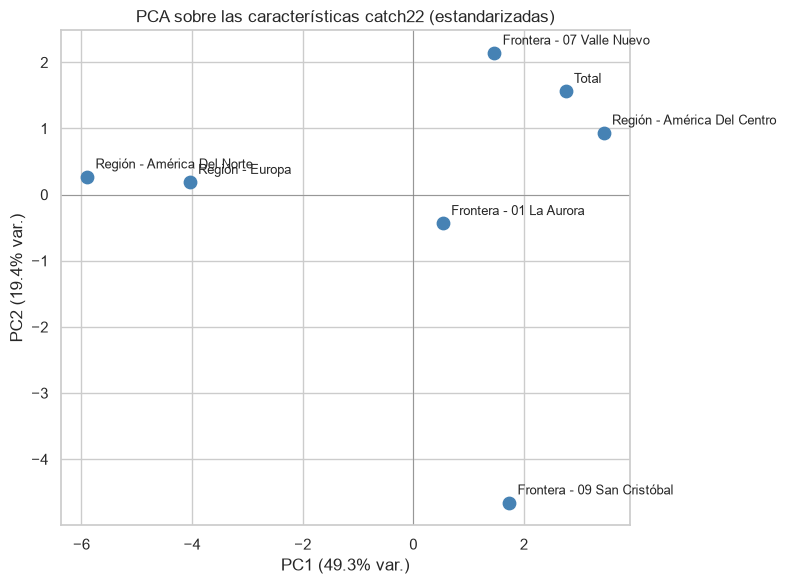

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
componentes = pca.fit_transform(matriz_z)
pca_df = pd.DataFrame(componentes, index=matriz_z.index, columns=["PC1", "PC2"])

print("Varianza explicada por componente:", np.round(pca.explained_variance_ratio_, 3))
print("Varianza explicada acumulada:", np.round(pca.explained_variance_ratio_.cumsum(), 3))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pca_df["PC1"], pca_df["PC2"], s=80, color="steelblue")
for nombre, fila in pca_df.iterrows():
    ax.annotate(nombre, (fila["PC1"], fila["PC2"]), textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
ax.set_title("PCA sobre las características catch22 (estandarizadas)")
plt.tight_layout()
plt.show()

### Clustering

Con solo 7 series, un clustering jerárquico (linkage completo, distancia euclidiana) es más informativo que fijar un número de clusters a priori: el dendrograma muestra a qué distancia se van uniendo las series.

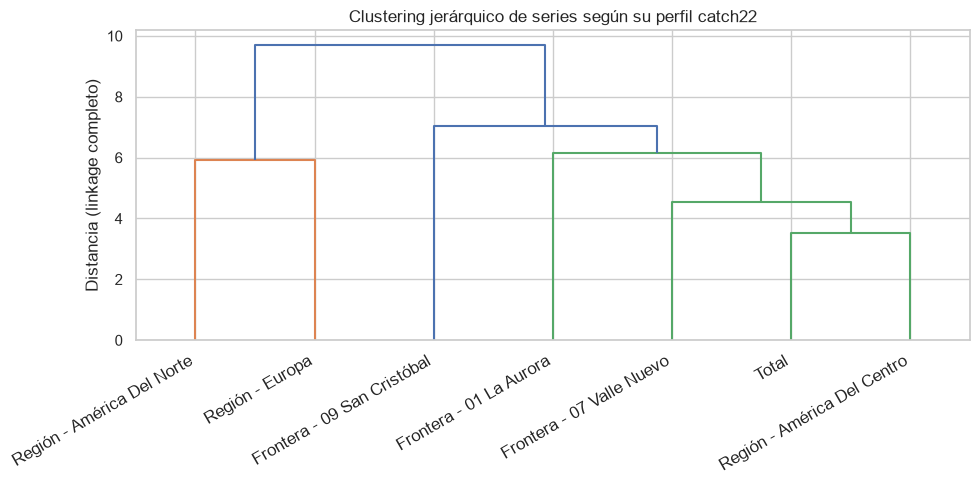

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

enlace = linkage(matriz_z.values, method="complete", metric="euclidean")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(enlace, labels=matriz_z.index.tolist(), ax=ax, color_threshold=0.7 * max(enlace[:, 2]))
ax.set_title("Clustering jerárquico de series según su perfil catch22")
ax.set_ylabel("Distancia (linkage completo)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Heatmap de características

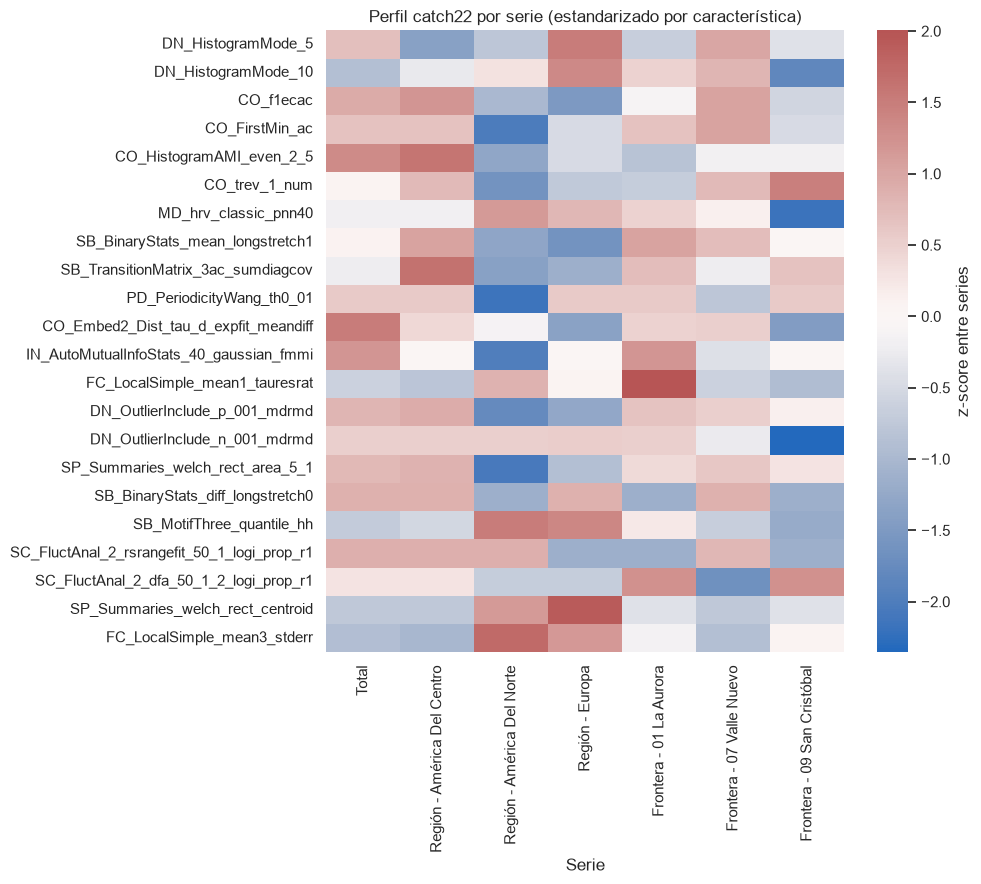

In [8]:
# Heatmap de las características estandarizadas (matriz_z), para comparar el perfil de cada serie.
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(matriz_z.T, cmap="vlag", center=0, ax=ax, cbar_kws={"label": "z-score entre series"})
ax.set_title("Perfil catch22 por serie (estandarizado por característica)")
plt.tight_layout()
plt.show()

### Matriz de correlaciones entre características

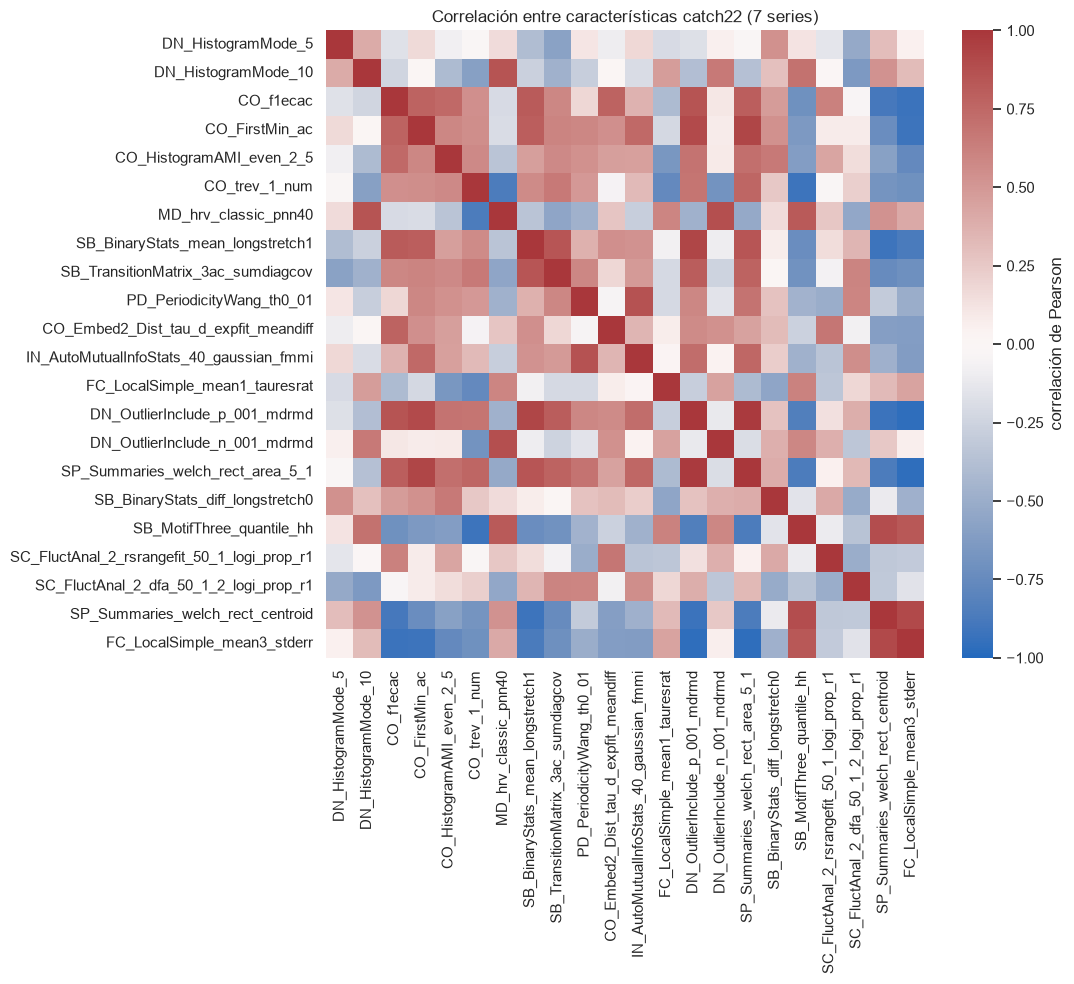

In [9]:
correlacion_features = matriz_z.corr()

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(correlacion_features, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "correlación de Pearson"})
ax.set_title("Correlación entre características catch22 (7 series)")
plt.tight_layout()
plt.show()

### Mapa de distancias entre series

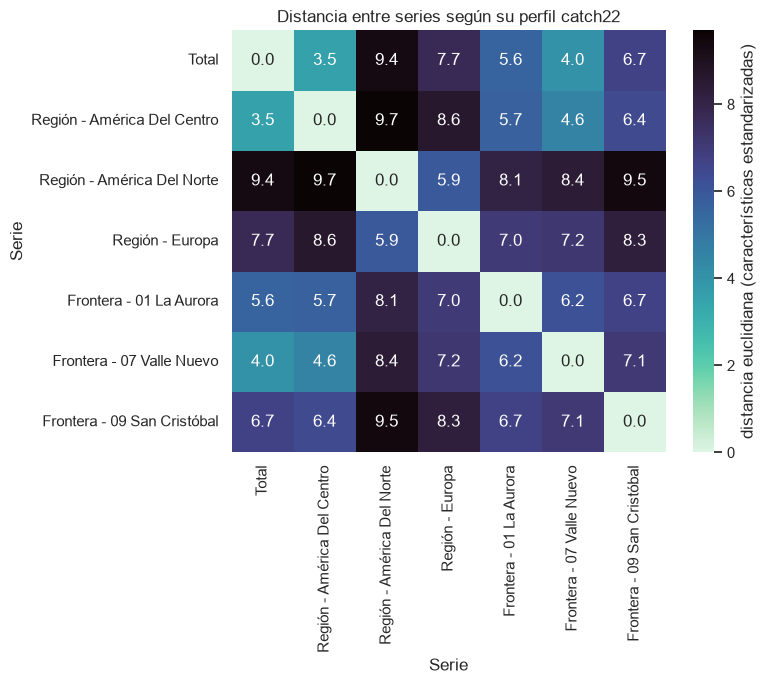

In [10]:
from scipy.spatial.distance import pdist, squareform

distancias = pd.DataFrame(
    squareform(pdist(matriz_z.values, metric="euclidean")),
    index=matriz_z.index,
    columns=matriz_z.index,
)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(distancias, cmap="mako_r", annot=True, fmt=".1f", ax=ax,
            cbar_kws={"label": "distancia euclidiana (características estandarizadas)"})
ax.set_title("Distancia entre series según su perfil catch22")
plt.tight_layout()
plt.show()

## **2.6. Análisis e interpretación**

### 2.7. ¿Cuáles series presentan comportamientos más similares?

Un grupo de 5 series muy parecidas:
Total, Región - América Del Centro y las tres fronteras (01 La Aurora, 07 Valle Nuevo, 09 San Cristóbal). En el dendrograma se van uniendo entre sí a distancias bajas (3.5–7.1), y en el PCA aparecen todas con PC1 positivo, agrupadas en el mismo lado del plano.
- El par más parecido de todos es Total y Región - América Del Centro** (distancia euclidiana ≈ 3.5, la menor de toda la matriz de distancias). Tiene sentido: América Del Centro es la región con más peso dentro del total de viajeros, así que su dinámica mensual domina la serie Total.

Un grupo aparte y muy distinto:
Región - América Del Norte y Región - Europa. Son las series más parecidas entre sí (distancia ≈ 5.9) pero las más *alejadas* de todo el resto (≈ 9.7 del otro grupo, la mayor distancia del análisis) — en el PCA quedan solas en el cuadrante de PC1 muy negativo. Esto se explica porque ambas series tuvieron varios meses en cero durante el confinamiento de 2020 (no hubo viajeros de esas regiones), lo que les da un perfil catch22 (más rachas constantes, distribución más concentrada) distinto al de las demás series, que nunca llegaron a cero.

### 2.8. ¿Qué características de catch22 fueron las más importantes para diferenciar las series?

Mirando los *loadings* (pesos) de los dos componentes principales, que juntos explican ~69% de la varianza:

**PC1 (49% de la varianza)** — domina la forma del espectro y la regularidad de la serie:
- SP_Summaries_welch_rect_area_5_1 — concentración de la energía espectral en bajas frecuencias
- SP_Summaries_welch_rect_centroid — concentración de la energía espectral en bajas frecuencias
- DN_OutlierInclude_p_001_mdrmd — qué tan rápido aparecen valores atípicos altos
- FC_LocalSimple_mean3_stderr — qué tan predecible es la serie con un promedio móvil simple
- SB_MotifThree_quantile_hh — patrones en la serie binarizada
- SB_BinaryStats_mean_longstretch1 — rachas en la serie binarizada

**PC2 (19% de la varianza)** — separa principalmente por outliers y fluctuación:
- DN_OutlierInclude_n_001_mdrmd — valores atípicos bajos
- MD_hrv_classic_pnn40 — variabilidad punto a punto
- CO_Embed2_Dist_tau_d_expfit_meandiff — ajuste del espacio de embedding
- SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1 — ajuste a un patrón de fluctuación tipo random-walk/DFA
- SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1 — ajuste a un patrón de fluctuación tipo random-walk/DFA

En resumen: lo que más separa a estas 7 series no es el nivel de viajeros (eso ya se elimina al estandarizar), sino **qué tan concentrada está su energía espectral, qué tan seguido y qué tan fuertes son sus valores atípicos, y qué tan predecible/regular es su patrón mes a mes** — justo las características que distinguen a América Del Norte y Europa (con meses en cero) del resto de series.